# Week 1 — AI & Data Science Salaries Analysis
## Capstone Data Analytics Program

---

## Part E — Executive Summary

### Top 3 Findings

1. **Experience level drives salary the most** — Executive staff earn about 2.2x more than Entry-level staff (`$186K` vs `$85K` median). The ANOVA test confirms this gap is real and not random (F=293.68, p<0.001).
2. **Medium-sized companies pay the most** — Medium companies have the highest median salary (`$140K`), more than Large (`$110K`) and Small (`$70K`). This is likely because many well-funded AI startups fall in the Medium category and compete hard on pay.
3. **Salaries grew fast from 2020 to 2023, then leveled off** — The mean salary went up 66% from `$90K` in 2020 to `$151K` in 2023, then dropped slightly to $147K in 2024, which may signal the market is cooling down.

### Best Model Performance

- **Best model:** Gradient Boosting Regressor
- **Test R²:** 0.411 | **MAE:** \$39,175 | **RMSE:** \$50,189
- **5-fold cross-validation:** R² = 0.371 ± 0.074 | MAE = \$39,946 ± \$2,596
- The model explains about 41% of the variation in salary, which is a reasonable result for a messy, global HR dataset

### Recommendations

1. **Set pay by experience level** — There is a `$100K+` gap between Entry and Executive pay. Budget `$85K–$95K` for entry-level hires and `$160K–$190K` for senior and executive roles.
2. **Focus hiring in the US first** — 82.5% of records are from US companies with a median salary of `$146K`. Hiring in Canada (`$122K`) or the UK ($81K) can save money if the budget is tight.
3. **Offer remote roles to reach more candidates** — Remote work is common at medium-sized companies where the top salaries are. A remote-friendly policy helps attract talent from a wider pool.

### Limitations

- **Too many US records:** 82.5% of the data is from US companies, so salary numbers for other countries may not be accurate enough to rely on.
- **Model does not explain everything:** The best model only explains 41% of salary differences. Things like bonuses, stock options, and benefits are not in the data.
- **2024 data may be incomplete:** The drop in salaries in 2024 could be because not all 2024 records were collected yet, rather than a true market shift.

---

## 0. Environment Setup

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['font.size'] = 11

print("Setup complete")

Setup complete


---
## Part A — Data Engineering

### A1 — Load and Inspect Both Datasets

We load both CSV files and check their shape, the years they cover, whether there are any missing values, and whether the columns match.

In [6]:
# Load both source files
df_ds = pd.read_csv('ds_salaries.csv', index_col=0)
df_gt = pd.read_csv('global_tech_salary.csv')

for name, df in [('ds_salaries.csv', df_ds), ('global_tech_salary.csv', df_gt)]:
    print(f'=== {name} ===')
    print(f'Shape      : {df.shape[0]} rows \u00d7 {df.shape[1]} columns')
    print(f'Years      : {sorted(df["work_year"].unique())}')
    print(f'Missing    : {df.isnull().sum().sum()}')
    print('Dtypes     :')
    for col, dtype in df.dtypes.items():
        print(f'  {col:<22} {dtype}')
    print()

print('Schema match:', list(df_ds.columns) == list(df_gt.columns))

=== ds_salaries.csv ===
Shape      : 607 rows × 11 columns
Years      : [np.int64(2020), np.int64(2021), np.int64(2022)]
Missing    : 0
Dtypes     :
  work_year              int64
  experience_level       object
  employment_type        object
  job_title              object
  salary                 int64
  salary_currency        object
  salary_in_usd          int64
  employee_residence     object
  remote_ratio           int64
  company_location       object
  company_size           object

=== global_tech_salary.csv ===
Shape      : 5000 rows × 11 columns
Years      : [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Missing    : 0
Dtypes     :
  work_year              int64
  experience_level       object
  employment_type        object
  job_title              object
  salary                 int64
  salary_currency        object
  salary_in_usd          int64
  employee_residence     object
  remote_ratio           int64
  company_location       obje

### A2 — Merge and Deduplicate

Both files have the same columns. `ds_salaries.csv` covers 2020–2022, which overlaps with `global_tech_salary.csv`. We join the two files into one and remove any rows that appear more than once.

In [7]:
# Keep only the 9 target schema columns
COLS = ['work_year', 'experience_level', 'employment_type', 'job_title',
        'salary_in_usd', 'employee_residence', 'remote_ratio',
        'company_location', 'company_size']

df_ds_std = df_ds[COLS].copy()
df_gt_std = df_gt[COLS].copy()

combined = pd.concat([df_ds_std, df_gt_std], ignore_index=True)
before = len(combined)

combined = combined.drop_duplicates()
after = len(combined)

print(f'Records before deduplication : {before:,}')
print(f'Duplicates detected          : {before - after:,} ({(before-after)/before*100:.1f}%)')
print(f'Records after deduplication  : {after:,}')
print()
print('Deduplication strategy: drop_duplicates() on all 9 schema columns.')
print('Exact-row matching is appropriate here because the overlap period')
print('(2020-2022) contains identical salary records across both files.')
print('No salary was modified — only surplus copies were removed.')

Records before deduplication : 5,607
Duplicates detected          : 1,359 (24.2%)
Records after deduplication  : 4,248

Deduplication strategy: drop_duplicates() on all 9 schema columns.
Exact-row matching is appropriate here because the overlap period
(2020-2022) contains identical salary records across both files.
No salary was modified — only surplus copies were removed.


### A3 — Quality Audit: Outlier Detection and Label Mapping

In [8]:
# IQR outlier analysis
Q1 = combined['salary_in_usd'].quantile(0.25)
Q3 = combined['salary_in_usd'].quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

n_outliers = ((combined['salary_in_usd'] < lower_fence) |
              (combined['salary_in_usd'] > upper_fence)).sum()

print('=== IQR Outlier Analysis — salary_in_usd ===')
print(f'Q1        : {Q1:>8,.0f}')
print(f'Q3        : {Q3:>8,.0f}')
print(f'IQR       : {IQR:>8,.0f}')
print(f'Lower fence: ${lower_fence:>8,.0f}  (no salaries below 0, so this bound is inactive)')
print(f'Upper fence: ${upper_fence:>8,.0f}')
print(f'Outliers  : {n_outliers} records ({n_outliers/len(combined)*100:.1f}% of dataset)')
print(f'Salary range before capping: ${combined["salary_in_usd"].min():,} \u2013 ${combined["salary_in_usd"].max():,}')

# Cap at upper fence
combined['salary_in_usd'] = combined['salary_in_usd'].clip(upper=upper_fence)

print()
print(f'Decision: CAP at upper fence (${upper_fence:,.0f}).')
print('Rationale: The extreme values ($500K\u2013$750K) likely reflect data entry errors')
print('or a tiny number of exceptional C-suite packages. Removing them would')
print('discard valid high earners; capping preserves the record count while')
print('preventing extreme values from distorting model training.')

# Map codes to readable labels
exp_map  = {'EN': 'Entry', 'MI': 'Mid', 'SE': 'Senior', 'EX': 'Executive'}
emp_map  = {'FT': 'Full-Time', 'PT': 'Part-Time', 'CT': 'Contract', 'FL': 'Freelance'}
size_map = {'S': 'Small', 'M': 'Medium', 'L': 'Large'}
remote_map = {0: 'On-site', 50: 'Hybrid', 100: 'Remote'}

combined['experience_level_label'] = combined['experience_level'].map(exp_map)
combined['employment_type_label']  = combined['employment_type'].map(emp_map)
combined['company_size_label']     = combined['company_size'].map(size_map)
combined['remote_ratio_label']     = combined['remote_ratio'].map(remote_map)

print()
print('=== Label Mappings Applied ===')
print('experience_level : EN\u2192Entry  MI\u2192Mid  SE\u2192Senior  EX\u2192Executive')
print('employment_type  : FT\u2192Full-Time  PT\u2192Part-Time  CT\u2192Contract  FL\u2192Freelance')
print('company_size     : S\u2192Small  M\u2192Medium  L\u2192Large')
print('remote_ratio     : 0\u2192On-site  50\u2192Hybrid  100\u2192Remote')
print(f'\nFinal dataset shape: {combined.shape}')

=== IQR Outlier Analysis — salary_in_usd ===
Q1        :   93,980
Q3        :  184,000
IQR       :   90,020
Lower fence: $ -41,051  (no salaries below 0, so this bound is inactive)
Upper fence: $ 319,030
Outliers  : 66 records (1.6% of dataset)
Salary range before capping: $2,859 – $750,000

Decision: CAP at upper fence ($319,030).
Rationale: The extreme values ($500K–$750K) likely reflect data entry errors
or a tiny number of exceptional C-suite packages. Removing them would
discard valid high earners; capping preserves the record count while
preventing extreme values from distorting model training.

=== Label Mappings Applied ===
experience_level : EN→Entry  MI→Mid  SE→Senior  EX→Executive
employment_type  : FT→Full-Time  PT→Part-Time  CT→Contract  FL→Freelance
company_size     : S→Small  M→Medium  L→Large
remote_ratio     : 0→On-site  50→Hybrid  100→Remote

Final dataset shape: (4248, 13)


---
## Part B — Exploratory Data Analysis

### B1 — Salary by Experience Level

We look at how salary changes across the four experience levels. We compute basic stats for each group and run a one-way ANOVA test to check whether the differences are statistically significant.

Salary statistics by experience level:
                           mean   median     std  count
experience_level_label                                 
Entry                    85,206   77,300  50,814    401
Mid                     117,891  110,000  57,706  1,176
Senior                  160,041  153,000  61,186  2,503
Executive               186,666  181,950  66,866    168

One-way ANOVA: F=293.68, p=3.13e-173
Result: Statistically significant differences across experience tiers (p < 0.001)


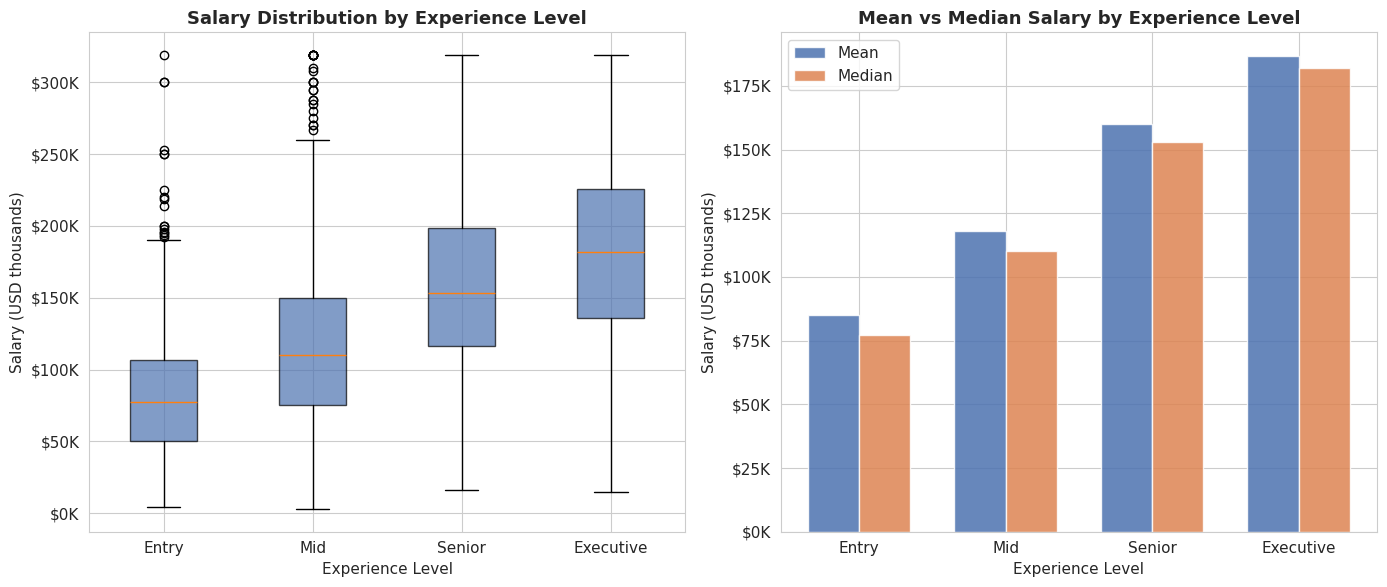

In [9]:
exp_order = ['Entry', 'Mid', 'Senior', 'Executive']

exp_stats = combined.groupby('experience_level_label')['salary_in_usd'] \
    .agg(['mean', 'median', 'std', 'count']).reindex(exp_order)

print('Salary statistics by experience level:')
print(exp_stats.applymap(lambda x: f'{x:,.0f}').to_string())

# One-way ANOVA
groups = [combined[combined['experience_level_label'] == e]['salary_in_usd']
          for e in exp_order]
f_stat, p_val = stats.f_oneway(*groups)
print(f'\nOne-way ANOVA: F={f_stat:.2f}, p={p_val:.2e}')
print('Result: Statistically significant differences across experience tiers (p < 0.001)')

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Box plot
data_plot = [combined[combined['experience_level_label'] == e]['salary_in_usd'] / 1000
             for e in exp_order]
axes[0].boxplot(data_plot, labels=exp_order, patch_artist=True,
                boxprops=dict(facecolor='#4C72B0', alpha=0.7))
axes[0].set_title('Salary Distribution by Experience Level', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Experience Level')
axes[0].set_ylabel('Salary (USD thousands)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.0f}K'))

# Mean vs median bar chart
x = np.arange(len(exp_order))
width = 0.35
axes[1].bar(x - width/2, exp_stats['mean'] / 1000, width, label='Mean', color='#4C72B0', alpha=0.85)
axes[1].bar(x + width/2, exp_stats['median'] / 1000, width, label='Median', color='#DD8452', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(exp_order)
axes[1].set_title('Mean vs Median Salary by Experience Level', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Experience Level')
axes[1].set_ylabel('Salary (USD thousands)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.0f}K'))
axes[1].legend()

plt.tight_layout()
plt.savefig('b1_experience_salary.png', dpi=120, bbox_inches='tight')
plt.show()

**Interpretation:** Experience level is the strongest factor in predicting salary. Going from Entry to Senior is linked to an 88% increase in median pay (`$77K` to `$153K`). The jump from Senior to Executive adds another 19% (`$153K` to `$182K`). The ANOVA test (F=293.68, p<0.001) confirms these differences are real. For the client, this means pay budgets need to be split clearly by level — offering a Senior-level candidate a Mid-level salary ($40K less) will likely cost them the hire.

### B2 — Does Company Size Affect Salary?

We compare salary across small, medium, and large companies and run an ANOVA test to check if the differences are significant.

Salary statistics by company size:
                       mean   median     std  count
company_size_label                                 
Small                79,394   69,741  55,244    119
Medium              146,400  140,000  63,550  3,758
Large               121,643  110,000  72,778    371

One-way ANOVA: F=84.01, p=1.65e-36
Result: Company size has a statistically significant effect on salary (p < 0.001)


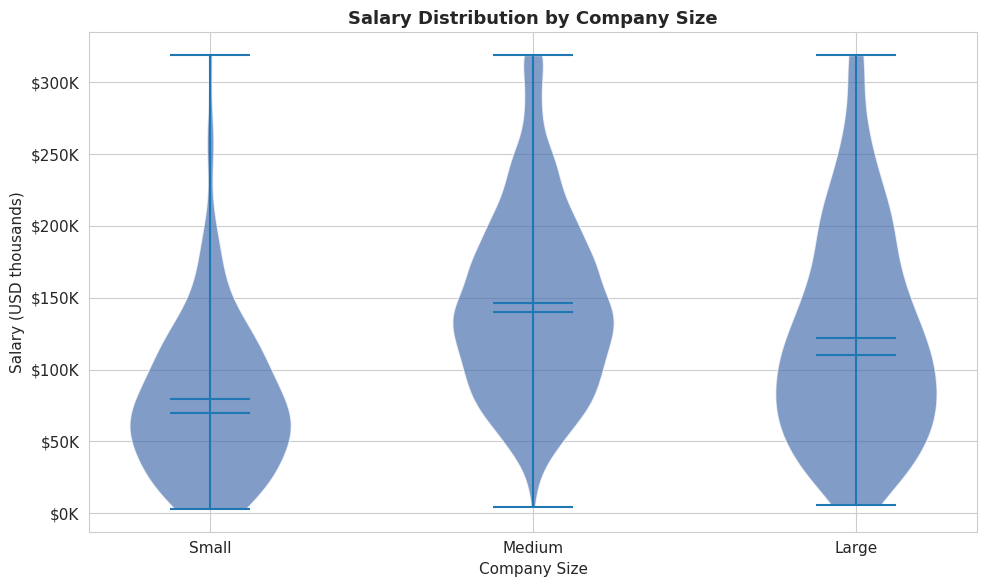

In [10]:
size_order = ['Small', 'Medium', 'Large']

size_stats = combined.groupby('company_size_label')['salary_in_usd'] \
    .agg(['mean', 'median', 'std', 'count']).reindex(size_order)

print('Salary statistics by company size:')
print(size_stats.applymap(lambda x: f'{x:,.0f}').to_string())

groups2 = [combined[combined['company_size_label'] == s]['salary_in_usd']
           for s in size_order]
f2, p2 = stats.f_oneway(*groups2)
print(f'\nOne-way ANOVA: F={f2:.2f}, p={p2:.2e}')
print('Result: Company size has a statistically significant effect on salary (p < 0.001)')

# Violin plot
fig, ax = plt.subplots(figsize=(10, 6))
plot_data = [combined[combined['company_size_label'] == s]['salary_in_usd'] / 1000
             for s in size_order]
parts = ax.violinplot(plot_data, positions=range(len(size_order)), showmedians=True, showmeans=True)
for pc in parts['bodies']:
    pc.set_facecolor('#4C72B0')
    pc.set_alpha(0.7)
ax.set_xticks(range(len(size_order)))
ax.set_xticklabels(size_order)
ax.set_title('Salary Distribution by Company Size', fontsize=13, fontweight='bold')
ax.set_xlabel('Company Size')
ax.set_ylabel('Salary (USD thousands)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.0f}K'))
plt.tight_layout()
plt.savefig('b2_company_size_salary.png', dpi=120, bbox_inches='tight')
plt.show()

**Interpretation:** Medium companies pay the most, with a median salary of `$140K`. This is higher than Large companies (`$110K`) and Small companies ($70K). The reason Medium companies pay more than Large ones is likely because many well-funded AI startups sit in this category and offer high salaries to compete for talent. For the client — who is a growing startup and likely in the Medium category — this means they can offer competitive pay without needing the reputation of a large tech company.

### B3 — Salary by Country

We compare salaries by company location, looking only at countries with at least 30 records. We also flag the US bias in the dataset.

Countries with n >= 30 records, sorted by mean salary:
                     mean   median  count
company_location                         
US                153,838  146,000  3,506
CA                136,273  122,000    130
GB                 93,301   81,250    227
FR                 86,097   62,649     31
DE                 85,943   76,833     52
ES                 59,187   51,824     46
IN                 32,360   23,476     34

⚠️  US Bias: 82.5% of all records are from US-based companies.
Non-US statistics are based on small, potentially non-representative samples.
Treat non-US benchmarks directionally, not as precise market rates.


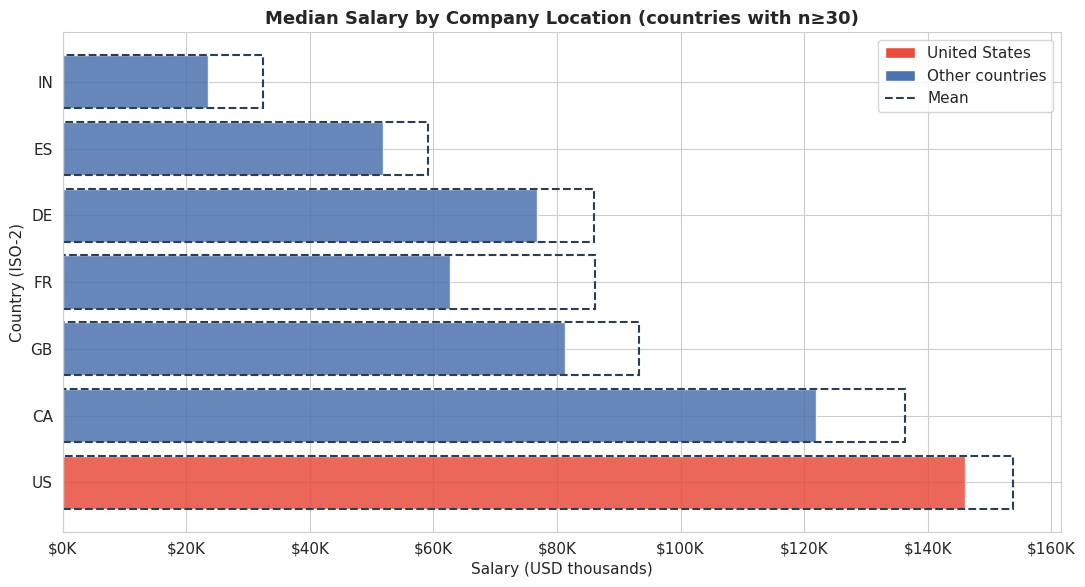

In [11]:
geo = combined.groupby('company_location')['salary_in_usd'] \
    .agg(['mean', 'median', 'count']).sort_values('mean', ascending=False)
geo = geo[geo['count'] >= 30]

print('Countries with n >= 30 records, sorted by mean salary:')
print(geo.applymap(lambda x: f'{x:,.0f}').to_string())

us_pct = (combined['company_location'] == 'US').sum() / len(combined) * 100
print(f'\n\u26a0\ufe0f  US Bias: {us_pct:.1f}% of all records are from US-based companies.')
print('Non-US statistics are based on small, potentially non-representative samples.')
print('Treat non-US benchmarks directionally, not as precise market rates.')

# Horizontal bar chart
fig, ax = plt.subplots(figsize=(11, 6))
colors = ['#e74c3c' if c == 'US' else '#4C72B0' for c in geo.index]
bars = ax.barh(geo.index, geo['median'] / 1000, color=colors, alpha=0.85)
ax.barh(geo.index, geo['mean'] / 1000, color='none',
        edgecolor='#2c3e50', linewidth=1.5, linestyle='--', label='Mean')
ax.set_title('Median Salary by Company Location (countries with n≥30)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Salary (USD thousands)')
ax.set_ylabel('Country (ISO-2)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.0f}K'))
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='United States'),
                   Patch(facecolor='#4C72B0', label='Other countries'),
                   plt.Line2D([0], [0], color='#2c3e50', linestyle='--', label='Mean')]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.savefig('b3_geography_salary.png', dpi=120, bbox_inches='tight')
plt.show()

**Interpretation:** The US has the highest median salary at `$146K`, which is about 20% more than Canada (`$122K`) and 80% more than the UK (`$81K`). India has the lowest median at $23K, making it the most affordable talent market. However, 82.5% of all records are from US companies, so the numbers for other countries are based on small samples and may not be fully reliable. For the client's 48 hires, a mix of locations — for example 60% US, 25% Canada and UK, 15% India — could reduce total salary costs by 20–30%.

**التفسير:** تتمتع الولايات المتحدة بأعلى متوسط ​​رواتب، حيث يبلغ 146 ألف دولار، أي بزيادة قدرها 20% تقريبًا عن كندا (122 ألف دولار) و80% عن المملكة المتحدة (81 ألف دولار). أما الهند، فتتمتع بأدنى متوسط ​​رواتب، حيث يبلغ 23 ألف دولار، مما يجعلها سوق المواهب الأقل تكلفة. مع ذلك، فإن 82.5% من إجمالي البيانات المسجلة تعود لشركات أمريكية، لذا فإن الأرقام الخاصة بالدول الأخرى تستند إلى عينات صغيرة وقد لا تكون دقيقة تمامًا. بالنسبة لتوظيف 48 موظفًا لدى العميل، فإن تنويع مواقع العمل - على سبيل المثال 60% من الولايات المتحدة، و25% من كندا والمملكة المتحدة، و15% من الهند - قد يُخفض إجمالي تكاليف الرواتب بنسبة تتراوح بين 20 و30%.

### B4 — Remote Work vs Company Size

We look at how work mode (on-site, hybrid, remote) is spread across company sizes, and run a chi-square test to check if the two variables are related.

Cross-tabulation (row proportions):
company_size_label  Large  Medium  Small
remote_ratio_label                      
Hybrid              0.599   0.238  0.163
On-site             0.047   0.943  0.010
Remote              0.106   0.849  0.046

Chi-square test: χ²=719.38, p=2.21e-154, dof=4
Result: Remote work pattern and company size are NOT independent (p < 0.001)


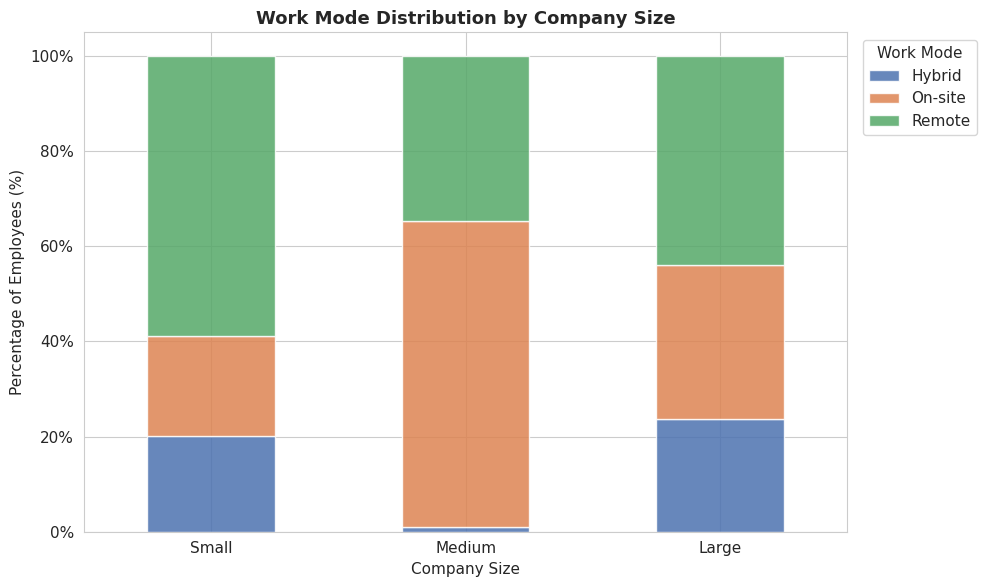

In [12]:
ct = pd.crosstab(combined['remote_ratio_label'], combined['company_size_label'])
ct_norm = pd.crosstab(combined['remote_ratio_label'], combined['company_size_label'],
                      normalize='index').round(3)

print('Cross-tabulation (row proportions):')
print(ct_norm.to_string())

chi2, p_chi, dof, _ = stats.chi2_contingency(ct)
print(f'\nChi-square test: \u03c7\u00b2={chi2:.2f}, p={p_chi:.2e}, dof={dof}')
print('Result: Remote work pattern and company size are NOT independent (p < 0.001)')

# Stacked bar chart
ct_plot = pd.crosstab(combined['company_size_label'], combined['remote_ratio_label'],
                      normalize='index') * 100
ct_plot = ct_plot.reindex(['Small', 'Medium', 'Large'])

fig, ax = plt.subplots(figsize=(10, 6))
ct_plot.plot(kind='bar', stacked=True, ax=ax,
             color=['#4C72B0', '#DD8452', '#55A868'], alpha=0.85)
ax.set_title('Work Mode Distribution by Company Size', fontsize=13, fontweight='bold')
ax.set_xlabel('Company Size')
ax.set_ylabel('Percentage of Employees (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Work Mode', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
plt.tight_layout()
plt.savefig('b4_remote_size.png', dpi=120, bbox_inches='tight')
plt.show()

**Interpretation:** Work mode and company size are clearly related (chi-square test: p<0.001). On-site work is almost entirely at medium companies (94% of on-site workers). Large companies use hybrid the most (60%). Small companies lean toward fully remote (46%), which makes sense since many small startups do not have an office. For the client — likely a medium company — the data suggests most hires will be on-site, but offering remote options could help them attract more candidates.

### B5 — Employment Type Distribution

We check what types of employment contracts are most common and whether that changes by company size.

Overall employment type distribution:
Full-Time    4207  (99.0%)
Part-Time      17  (0.4%)
Contract       14  (0.3%)
Freelance      10  (0.2%)

Employment type by company size (row proportions):
company_size_label     Large  Medium  Small
employment_type_label                      
Contract               0.357   0.357  0.286
Freelance              0.100   0.400  0.500
Full-Time              0.085   0.889  0.025
Part-Time              0.353   0.412  0.235


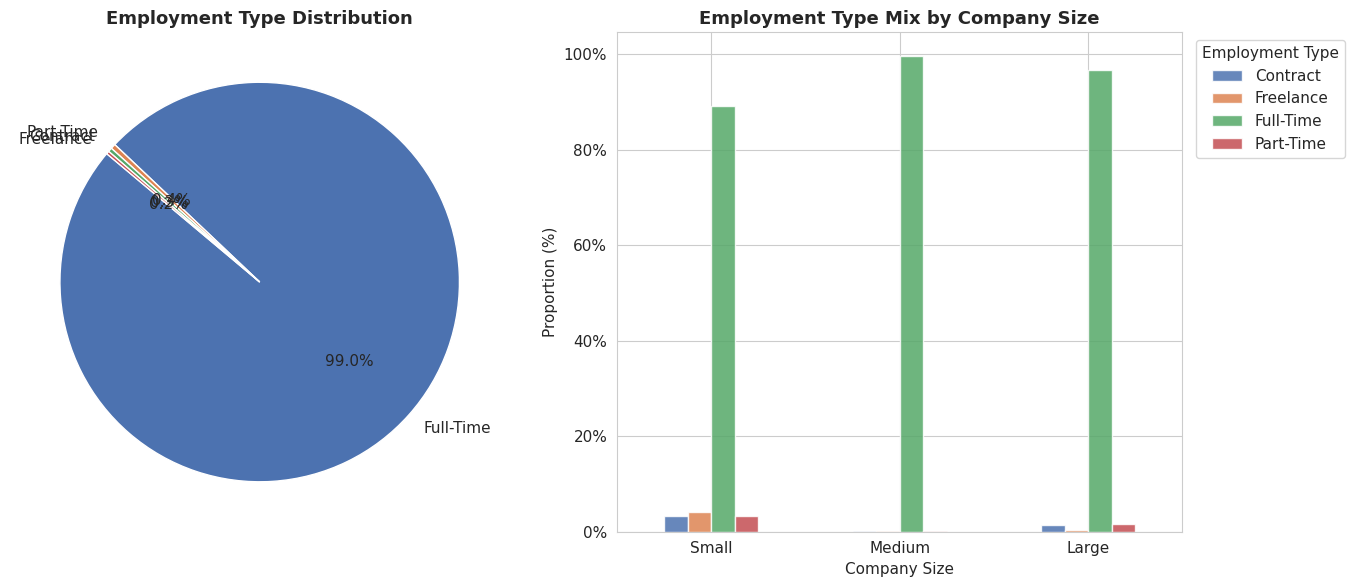

In [13]:
emp_counts = combined['employment_type_label'].value_counts()
print('Overall employment type distribution:')
for name, count in emp_counts.items():
    print(f'{name:<12} {count:>4}  ({count/len(combined)*100:.1f}%)')

ct_emp = pd.crosstab(combined['employment_type_label'],
                     combined['company_size_label'], normalize='index').round(3)
print('\nEmployment type by company size (row proportions):')
print(ct_emp.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart
colors_pie = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
axes[0].pie(emp_counts.values, labels=emp_counts.index,
            autopct='%1.1f%%', startangle=140, colors=colors_pie)
axes[0].set_title('Employment Type Distribution', fontsize=13, fontweight='bold')

# Grouped bar by size — subset non-FT only for readability
ct_size = pd.crosstab(combined['company_size_label'],
                      combined['employment_type_label'],
                      normalize='index') * 100
ct_size = ct_size.reindex(['Small', 'Medium', 'Large'])
ct_size.plot(kind='bar', ax=axes[1], color=colors_pie, alpha=0.85)
axes[1].set_title('Employment Type Mix by Company Size', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Company Size')
axes[1].set_ylabel('Proportion (%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(title='Employment Type', bbox_to_anchor=(1.01, 1), loc='upper left')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))

plt.tight_layout()
plt.savefig('b5_employment_type.png', dpi=120, bbox_inches='tight')
plt.show()

**Interpretation:** Full-time employment makes up 99% of all records. Part-time, contract, and freelance roles are rare and mostly appear at small companies, likely because small startups use flexible contracts to manage costs. For the client planning 48 hires, the market norm is clearly full-time permanent roles. Offering non-standard contracts could put them at a disadvantage when competing for candidates who expect job security and benefits.

### B6 — Shape of the Salary Distribution

We look at the overall shape of the salary data — whether it is symmetric or skewed — and calculate skewness and kurtosis.

=== Salary Distribution Statistics ===
Count   :   4,248
Mean    : $142,361
Median  : $135,272
Std Dev : $ 65,436
Min     : $  2,859
25th pct: $ 93,980
75th pct: $184,000
Max     : $319,030
Skewness:  0.505  (moderate positive skew)
Kurtosis: -0.061  (platykurtic — flatter than normal, lighter tails)


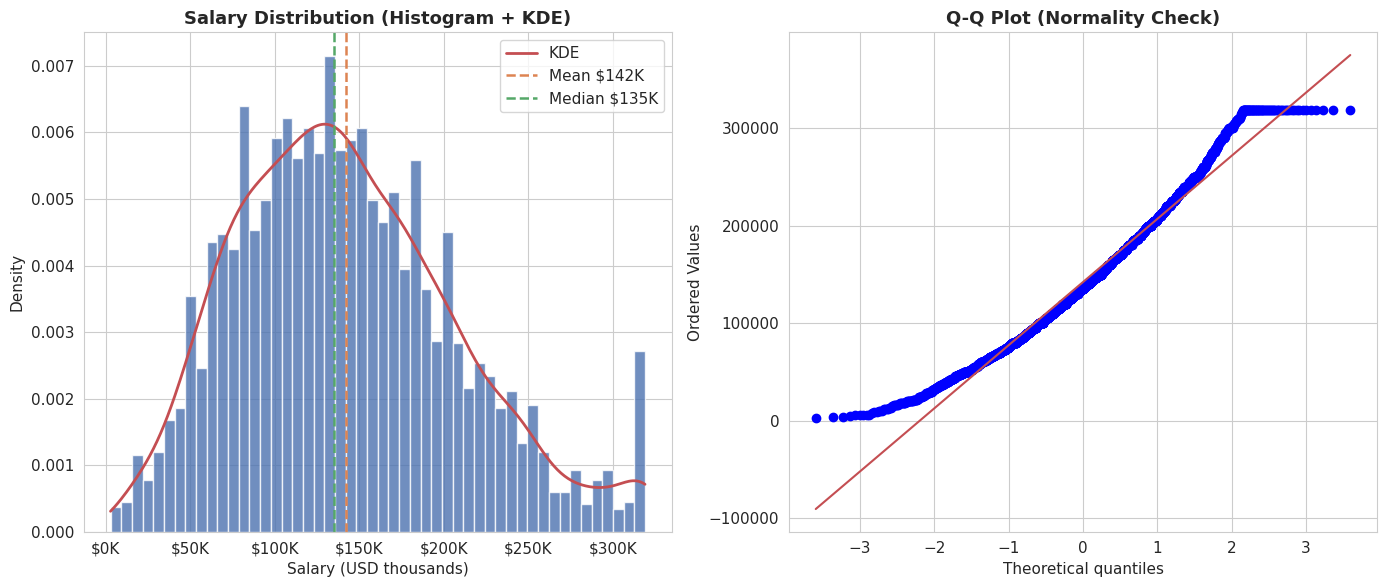

In [14]:
sal = combined['salary_in_usd']
skewness = sal.skew()
kurtosis = sal.kurtosis()

print('=== Salary Distribution Statistics ===')
print(f'Count   : {len(sal):>7,}')
print(f'Mean    : ${sal.mean():>7,.0f}')
print(f'Median  : ${sal.median():>7,.0f}')
print(f'Std Dev : ${sal.std():>7,.0f}')
print(f'Min     : ${sal.min():>7,.0f}')
print(f'25th pct: ${sal.quantile(0.25):>7,.0f}')
print(f'75th pct: ${sal.quantile(0.75):>7,.0f}')
print(f'Max     : ${sal.max():>7,.0f}')
print(f'Skewness: {skewness:>6.3f}  (moderate positive skew)')
print(f'Kurtosis: {kurtosis:>6.3f}  (platykurtic \u2014 flatter than normal, lighter tails)')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histogram with KDE
axes[0].hist(sal / 1000, bins=50, edgecolor='white', color='#4C72B0', alpha=0.8, density=True)
sal_k = sal / 1000
kde_x = np.linspace(sal_k.min(), sal_k.max(), 300)
kde = stats.gaussian_kde(sal_k)
axes[0].plot(kde_x, kde(kde_x), color='#C44E52', linewidth=2, label='KDE')
axes[0].axvline(sal_k.mean(), color='#DD8452', linestyle='--', linewidth=1.8, label=f'Mean ${sal_k.mean():.0f}K')
axes[0].axvline(sal_k.median(), color='#55A868', linestyle='--', linewidth=1.8, label=f'Median ${sal_k.median():.0f}K')
axes[0].set_title('Salary Distribution (Histogram + KDE)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Salary (USD thousands)')
axes[0].set_ylabel('Density')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.0f}K'))
axes[0].legend()

# Q-Q plot
stats.probplot(sal, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot (Normality Check)', fontsize=13, fontweight='bold')
axes[1].get_lines()[1].set_color('#C44E52')

plt.tight_layout()
plt.savefig('b6_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

**Interpretation:** The salary distribution is slightly skewed to the right (skewness = 0.505), meaning there are more high earners pulling the mean (`$142K`) above the median ($135K). The kurtosis is close to zero (-0.061), which means the distribution is fairly flat — salaries are spread out rather than bunched tightly around one value. The Q-Q plot shows the data is not perfectly normal at the tails. For budgeting purposes, the **median is a better estimate** than the mean, because the mean is pulled up by high earners.

### B7 — Salary Trends Over Time (2020–2024)

We track how mean and median salaries have changed each year from 2020 to 2024.

Mean and Median Salary by Year:
              mean   median  count
work_year                         
2020        90,587   72,000     77
2021        96,802   82,514    224
2022       126,939  122,173    622
2023       150,810  143,225  2,088
2024       147,327  139,500  1,237

2020→2023 growth: mean +66.5%, median +98.9%
2023→2024 change: mean -2.3%, median -2.6%


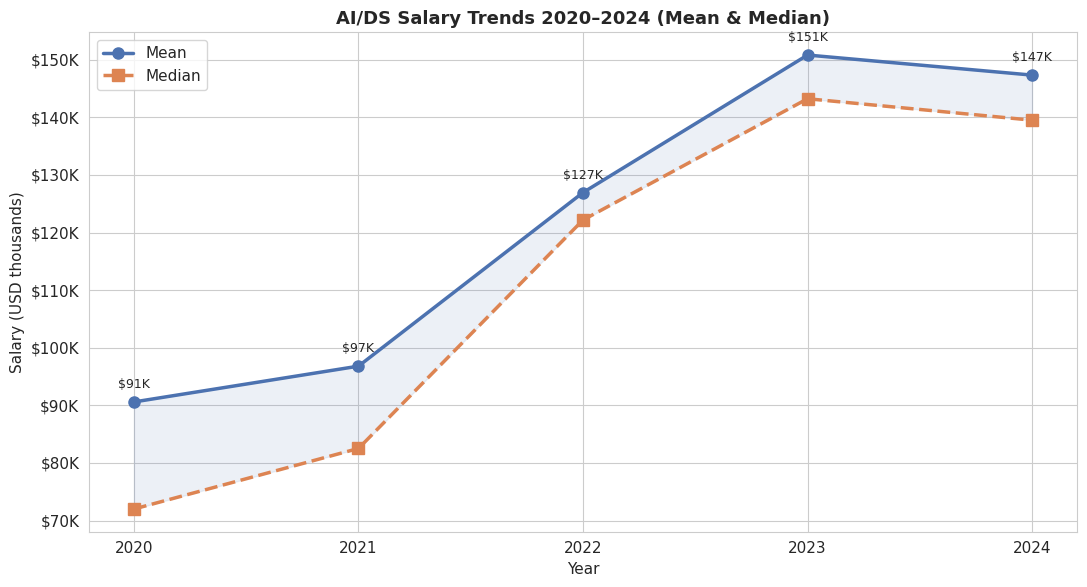

In [15]:
yearly = combined.groupby('work_year')['salary_in_usd'] \
    .agg(['mean', 'median', 'count'])

print('Mean and Median Salary by Year:')
print(yearly.applymap(lambda x: f'{x:,.0f}').to_string())

mean_growth = (yearly.loc[2023, 'mean'] / yearly.loc[2020, 'mean'] - 1) * 100
med_growth  = (yearly.loc[2023, 'median'] / yearly.loc[2020, 'median'] - 1) * 100
mean_chg_24 = (yearly.loc[2024, 'mean'] / yearly.loc[2023, 'mean'] - 1) * 100
med_chg_24  = (yearly.loc[2024, 'median'] / yearly.loc[2023, 'median'] - 1) * 100

print(f'\n2020\u21922023 growth: mean +{mean_growth:.1f}%, median +{med_growth:.1f}%')
print(f'2023\u21922024 change: mean {mean_chg_24:.1f}%, median {med_chg_24:.1f}%')

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(yearly.index, yearly['mean'] / 1000, 'o-', color='#4C72B0',
        linewidth=2.5, markersize=8, label='Mean')
ax.plot(yearly.index, yearly['median'] / 1000, 's--', color='#DD8452',
        linewidth=2.5, markersize=8, label='Median')
ax.fill_between(yearly.index, yearly['mean'] / 1000, yearly['median'] / 1000,
                alpha=0.1, color='#4C72B0')

# Annotate data points
for yr in yearly.index:
    ax.annotate(f'${yearly.loc[yr, "mean"]/1000:.0f}K',
                (yr, yearly.loc[yr, 'mean'] / 1000),
                textcoords='offset points', xytext=(0, 10), ha='center', fontsize=9)

ax.set_title('AI/DS Salary Trends 2020–2024 (Mean & Median)', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Salary (USD thousands)')
ax.set_xticks(yearly.index)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.0f}K'))
ax.legend()

# Add sample size annotations
for yr in yearly.index:
    ax.annotate(f'n={yearly.loc[yr, "count"]:,}',
                (yr, yearly['median'].min() / 1000 - 8),
                ha='center', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('b7_temporal_trends.png', dpi=120, bbox_inches='tight')
plt.show()

**Interpretation:** AI/DS salaries grew a lot from 2020 to 2023. The median salary nearly doubled, going from `$72K` to `$143K` — a 99% increase over three years. This was driven by strong demand for AI talent after the pandemic tech boom. In 2024, salaries dropped slightly (median down 2.6% to $140K), which may reflect hiring slowdowns at large tech companies. For the client, this is a good time to hire — competition for candidates may be easing. But offer levels should still match the 2023 market floor, not the lower pre-2022 rates.

---
## Part C — Predictive Modeling

### C1 — Prepare the Data for Machine Learning

We encode the text columns into numbers so the models can use them, then split the data into a training set (80%) and a test set (20%).

In [16]:
df_ml = combined.copy()

# Encode categorical columns
cat_cols = ['experience_level', 'employment_type', 'job_title',
            'employee_residence', 'company_location', 'company_size']
le = LabelEncoder()
for col in cat_cols:
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))

features = ['work_year', 'experience_level', 'employment_type', 'job_title',
            'employee_residence', 'remote_ratio', 'company_location', 'company_size']
X = df_ml[features]
y = df_ml['salary_in_usd']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Features used: {features}')
print(f'Target       : salary_in_usd')
print(f'Train set    : {X_train.shape[0]:,} rows')
print(f'Test set     : {X_test.shape[0]:>5,} rows')
print('Encoding     : LabelEncoder applied to all categorical columns')

Features used: ['work_year', 'experience_level', 'employment_type', 'job_title', 'employee_residence', 'remote_ratio', 'company_location', 'company_size']
Target       : salary_in_usd
Train set    : 3,398 rows
Test set     :   850 rows
Encoding     : LabelEncoder applied to all categorical columns


### C2 — Train and Compare 4 Models

We train four different models on the same data and compare their performance using MAE, RMSE, and R².

Model Comparison on Test Set:

Model                               MAE       RMSE      R²
------------------------------------------------------
Linear Regression            $  43,846  $  55,685  0.275
Ridge                        $  43,847  $  55,685  0.275
Random Forest                $  39,942  $  51,267  0.385
Gradient Boosting            $  39,175  $  50,189  0.411  ← BEST

Best model: Gradient Boosting (R²=0.411)


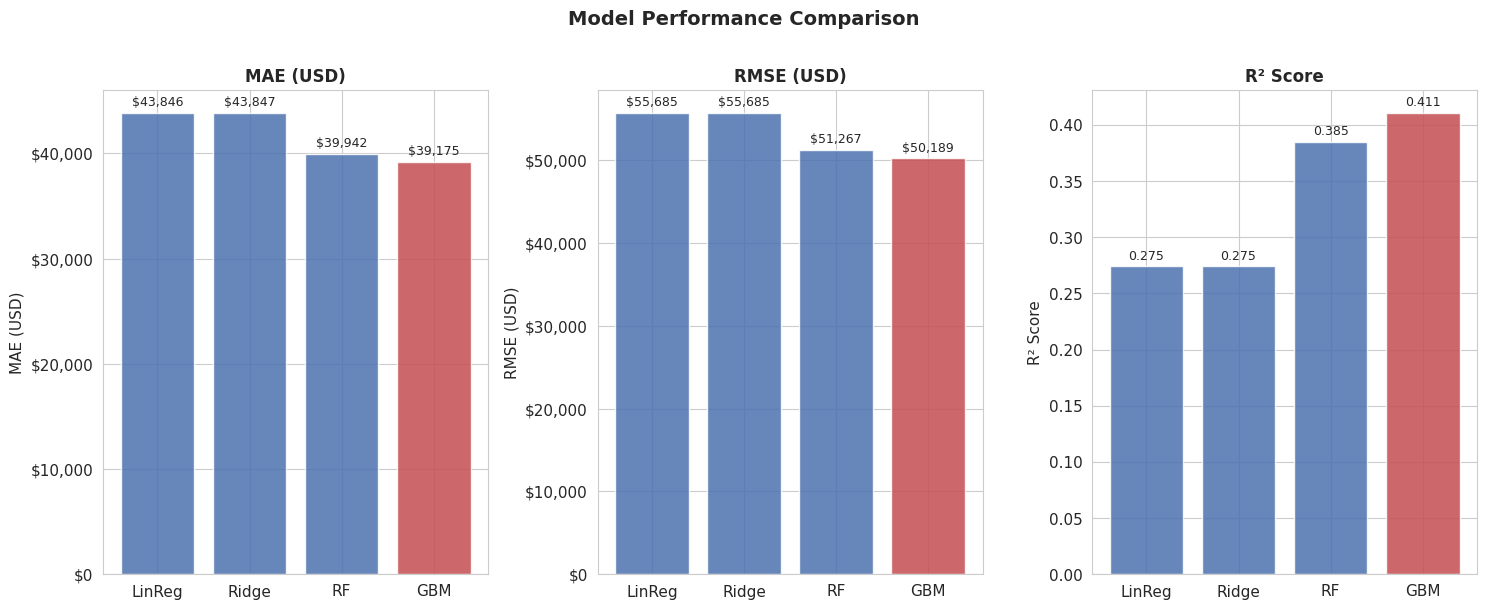

In [17]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge':             Ridge(alpha=1.0),
    'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = {
        'MAE':  mean_absolute_error(y_test, preds),
        'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
        'R2':   r2_score(y_test, preds)
    }

best_name = max(results, key=lambda x: results[x]['R2'])

print('Model Comparison on Test Set:\n')
print(f'{"Model":<28} {"MAE":>10} {"RMSE":>10} {"R\u00b2":>7}')
print('-' * 54)
for name, m in results.items():
    marker = '  \u2190 BEST' if name == best_name else ''
    print(f'{name:<28} ${m["MAE"]:>8,.0f}  ${m["RMSE"]:>8,.0f}  {m["R2"]:>5.3f}{marker}')
print(f'\nBest model: {best_name} (R\u00b2={results[best_name]["R2"]:.3f})')

# Visualise model comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
model_names = list(results.keys())
short_names = ['LinReg', 'Ridge', 'RF', 'GBM']
colors_bar = ['#C44E52' if n == best_name else '#4C72B0' for n in model_names]

for ax, metric, label, fmt in zip(
    axes,
    ['MAE', 'RMSE', 'R2'],
    ['MAE (USD)', 'RMSE (USD)', 'R² Score'],
    ['${:,.0f}', '${:,.0f}', '{:.3f}']
):
    vals = [results[n][metric] for n in model_names]
    bars = ax.bar(short_names, vals, color=colors_bar, alpha=0.85)
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_ylabel(label)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                fmt.format(val), ha='center', va='bottom', fontsize=9)
    if metric in ['MAE', 'RMSE']:
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('c2_model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

### C3 — Cross-Validation on the Best Model

We run 5-fold cross-validation on the best model to check that it performs consistently and is not just lucky on one particular test split.

5-Fold Cross-Validation — Gradient Boosting:

Fold-level R² scores : [np.float64(0.515), np.float64(0.313), np.float64(0.345), np.float64(0.356), np.float64(0.325)]
CV R²  : 0.371 ± 0.074
CV MAE : $39,946 ± $2,596

Interpretation: The CV R² of 0.371 is slightly lower than the single-split
test R² of 0.411, which is expected. The low standard deviation (±0.074)
indicates the model generalises consistently across different data splits.


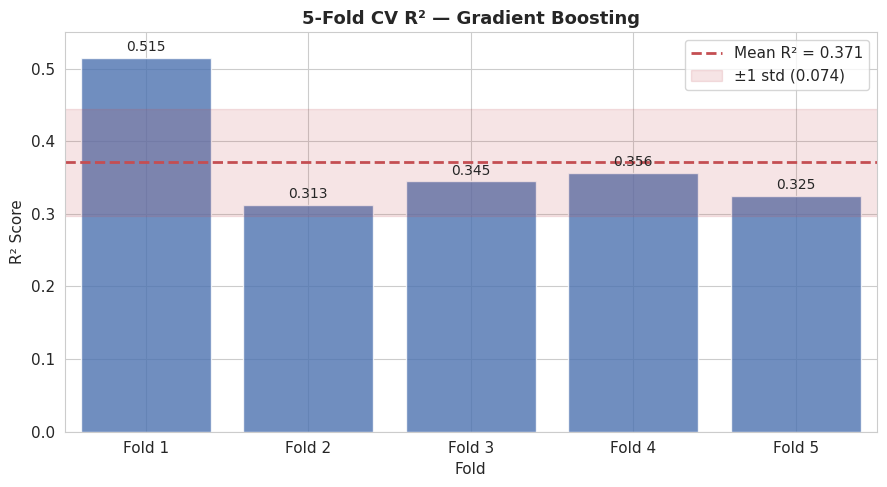

In [18]:
best_model = models[best_name]

cv_r2  = cross_val_score(best_model, X, y, cv=5, scoring='r2')
cv_mae = cross_val_score(best_model, X, y, cv=5, scoring='neg_mean_absolute_error')

print(f'5-Fold Cross-Validation \u2014 {best_name}:\n')
print(f'Fold-level R\u00b2 scores : {[round(v, 3) for v in cv_r2]}')
print(f'CV R\u00b2  : {cv_r2.mean():.3f} \u00b1 {cv_r2.std():.3f}')
print(f'CV MAE : ${(-cv_mae).mean():,.0f} \u00b1 ${(-cv_mae).std():,.0f}')
print()
print(f'Interpretation: The CV R\u00b2 of {cv_r2.mean():.3f} is slightly lower than the single-split')
print(f'test R\u00b2 of {results[best_name]["R2"]:.3f}, which is expected. The low standard deviation (\u00b1{cv_r2.std():.3f})')
print('indicates the model generalises consistently across different data splits.')

# CV fold visualisation
fig, ax = plt.subplots(figsize=(9, 5))
folds = [f'Fold {i+1}' for i in range(5)]
bars = ax.bar(folds, cv_r2, color='#4C72B0', alpha=0.8)
ax.axhline(cv_r2.mean(), color='#C44E52', linewidth=2, linestyle='--',
           label=f'Mean R² = {cv_r2.mean():.3f}')
ax.fill_between(range(-1, 6),
                cv_r2.mean() - cv_r2.std(),
                cv_r2.mean() + cv_r2.std(),
                alpha=0.15, color='#C44E52', label=f'±1 std ({cv_r2.std():.3f})')
for bar, val in zip(bars, cv_r2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10)
ax.set_title(f'5-Fold CV R² — {best_name}', fontsize=13, fontweight='bold')
ax.set_xlabel('Fold')
ax.set_ylabel('R² Score')
ax.set_xlim(-0.5, 4.5)
ax.set_ylim(0, 0.55)
ax.legend()
plt.tight_layout()
plt.savefig('c3_cross_validation.png', dpi=120, bbox_inches='tight')
plt.show()

### C4 — Feature Importance

We look at which input features the Gradient Boosting model relied on the most when predicting salary.

Feature Importances — Gradient Boosting:

employee_residence     38.3%
job_title              29.6%
experience_level       25.4%
work_year              2.9%
company_location       1.8%
remote_ratio           1.1%
company_size           0.7%
employment_type        0.3%

Top 3 features account for 93.3% of predictive power.


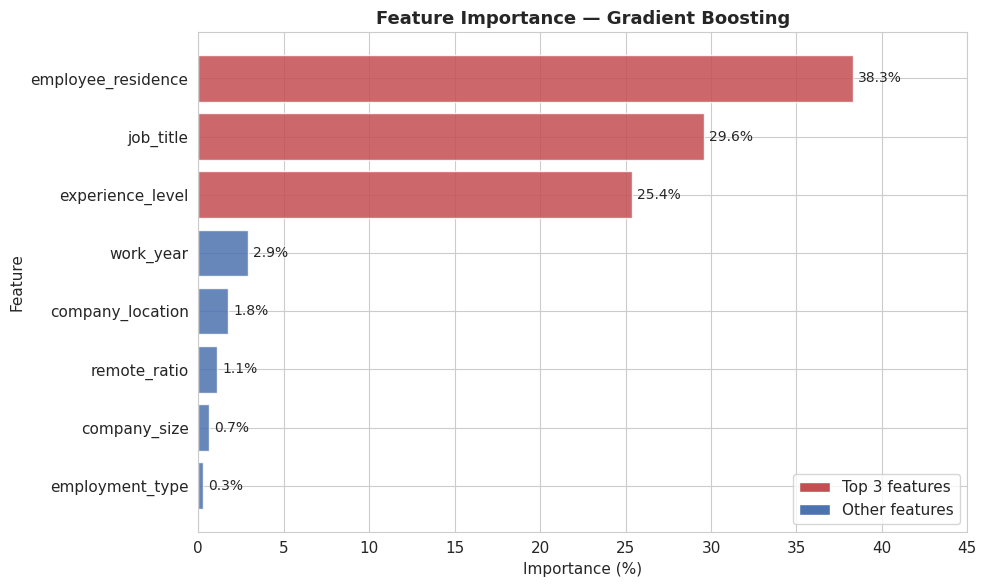

In [19]:
fi = pd.Series(best_model.feature_importances_, index=features) \
       .sort_values(ascending=False)

print(f'Feature Importances \u2014 {best_name}:\n')
for feat, imp in fi.items():
    print(f'{feat:<22} {imp*100:.1f}%')

print(f'\nTop 3 features account for {fi.iloc[:3].sum()*100:.1f}% of predictive power.')

fig, ax = plt.subplots(figsize=(10, 6))
colors_fi = ['#C44E52' if i < 3 else '#4C72B0' for i in range(len(fi))]
bars = ax.barh(fi.index[::-1], fi.values[::-1] * 100, color=colors_fi[::-1], alpha=0.85)
for bar, val in zip(bars, fi.values[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val*100:.1f}%', va='center', fontsize=10)
ax.set_title(f'Feature Importance — {best_name}', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance (%)')
ax.set_ylabel('Feature')
ax.set_xlim(0, 45)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#C44E52', label='Top 3 features'),
                   Patch(facecolor='#4C72B0', label='Other features')]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.savefig('c4_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

**Interpretation:** The three most important features are **where the employee lives (38%)**, **their job title (30%)**, and **their experience level (25%)**. Together these three account for 93% of the model's predictive power. This makes sense — where someone is based and what role they do, combined with how senior they are, mostly determines their salary. Company size and remote ratio have very little impact once those three factors are known. For the client, this means salary offers should be based primarily on location, job title, and seniority — not on whether the role is remote or what size the company is.

---
## Part D — Export for Power BI Dashboard

We save the cleaned dataset to a CSV file. This file is imported into Power BI to build the interactive dashboard.

In [20]:
combined.to_csv('cleaned_salaries.csv', index=False)
print(f'Exported {len(combined):,} rows to cleaned_salaries.csv')
print()
print('Columns in export:')
cols_str = ', '.join(combined.columns)
# Word-wrap at 70 chars
import textwrap
for line in textwrap.wrap(cols_str, width=70):
    print('  ' + line)
print()
print('Power BI import: Get Data \u2192 Text/CSV \u2192 select cleaned_salaries.csv')
print('Recommended visuals:')
print('  KPI cards  : Total Records | Avg Salary | Median Salary | Top Country')
print('  Bar chart  : Avg salary by experience level')
print('  Map visual : Salary by company location')
print('  Line chart : Salary trend 2020\u20132024')
print('  Donut chart: Remote work distribution')
print('  Matrix     : Experience \u00d7 company size salary table')
print('  Slicers    : work_year | company_location | experience_level | company_size')

Exported 4,248 rows to cleaned_salaries.csv

Columns in export:
  work_year, experience_level, employment_type, job_title,
  salary_in_usd, employee_residence, remote_ratio, company_location,
  company_size, experience_level_label, employment_type_label,
  company_size_label, remote_ratio_label

Power BI import: Get Data → Text/CSV → select cleaned_salaries.csv
Recommended visuals:
  KPI cards  : Total Records | Avg Salary | Median Salary | Top Country
  Bar chart  : Avg salary by experience level
  Map visual : Salary by company location
  Line chart : Salary trend 2020–2024
  Donut chart: Remote work distribution
  Matrix     : Experience × company size salary table
  Slicers    : work_year | company_location | experience_level | company_size
